# Practical ML – Medical Insurance Price Prediction


In [ ]:
# ============================================================
# 0) Install + Imports
# ============================================================

# Core
import os, sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import TransformedTargetRegressor

from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Optional (Colab): download helper
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False


In [ ]:
# ==============================================================
# 1) Load training & test data from Google Drive
# ==============================================================

import pandas as pd

# ---------------------------
# Load TRAIN data
# ---------------------------
train_drive_url = "https://drive.google.com/file/d/122kxiprQhzR123mGnyGxSERg854FmbBF/view?usp=sharing"

train_file_id = train_drive_url.split('/d/')[1].split('/')[0]
train_download_url = f"https://drive.google.com/uc?id={train_file_id}"

df_train = pd.read_csv(train_download_url)

print("Train shape:", df_train.shape)
display(df_train.head())


# ---------------------------
# Load TEST data
# ---------------------------
test_drive_url = "https://drive.google.com/file/d/1qZIgsTvpF4acFXosreetuGZyYaOjhSgM/view?usp=sharing"

test_file_id = test_drive_url.split('/d/')[1].split('/')[0]
test_download_url = f"https://drive.google.com/uc?id={test_file_id}"

df_test = pd.read_csv(test_download_url)

print("Test shape:", df_test.shape)
display(df_test.head())

Train shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Test shape: (267, 6)


,age,sex,bmi,children,smoker,region
0,58,0,30.338722,0,0,1
1,60,0,24.324606,0,0,0
2,27,0,18.228846,3,0,1
3,24,0,40.426077,0,1,2
4,19,0,35.872515,0,0,0


In [ ]:
# ============================================================
# 2) Identify Target / ID Columns
# ============================================================

if "charges" in df_train.columns:
    y_col = "charges"
elif "Target" in df_train.columns:
    y_col = "Target"
elif "TARGET" in df_train.columns:
    y_col = "TARGET"
else:
    raise ValueError("Target column not found. Expected 'charges' or 'Target'/'TARGET' in training data.")

# For test ID:
if "ID" in df_test.columns:
    id_col = "ID"
elif "id" in df_test.columns:
    id_col = "id"
else:
    id_col = None

print("Using target column:", y_col)
print("Using test ID column:", id_col)


Using target column: charges
Using test ID column: None


In [ ]:
# ============================================================
# 3) Feature Engineering (Safe, train+test consistent)
# ============================================================
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Ensure smoker_num always exists (0/1)
    if "smoker" in out.columns:
        if out["smoker"].dtype == object:
            mapped = out["smoker"].astype(str).str.lower().map({"yes": 1, "no": 0})
            out["smoker_num"] = mapped.fillna(0).astype(int)
        else:
            out["smoker_num"] = pd.to_numeric(out["smoker"], errors="coerce").fillna(0).astype(int)
    else:
        out["smoker_num"] = 0

    # Core interactions / nonlinear terms
    if "bmi" in out.columns and "age" in out.columns:
        out["bmi_x_age"] = out["bmi"] * out["age"]
        out["bmi_sq"] = out["bmi"] ** 2

    if "bmi" in out.columns:
        out["bmi_x_smoker"] = out["bmi"] * out["smoker_num"]

    if "age" in out.columns:
        out["age_x_smoker"] = out["age"] * out["smoker_num"]

    if "children" in out.columns and "age" in out.columns:
        out["children_x_age"] = out["children"] * out["age"]

    return out

df_train_fe = add_features(df_train)
df_test_fe  = add_features(df_test)

X = df_train_fe.drop(columns=[y_col]).copy()
y = df_train_fe[y_col].copy()

print("X shape:", X.shape, " y shape:", y.shape)


X shape: (1338, 12)  y shape: (1338,)


In [ ]:
# ============================================================
# 4) Preprocessing Pipeline (Numeric + Categorical)
# ============================================================
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)


Numeric cols: ['age', 'bmi', 'children', 'smoker_num', 'bmi_x_age', 'bmi_sq', 'bmi_x_smoker', 'age_x_smoker', 'children_x_age']
Categorical cols: ['sex', 'smoker', 'region']


In [ ]:
# ============================================================
# 5) Unified Train/Valid Split (used for ALL model comparison)
# ============================================================
X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_tr.shape, "Valid:", X_va.shape)


Train: (1070, 12) Valid: (268, 12)


In [ ]:
# ============================================================
# 6) Train Models (Sklearn/XGBoost) + Compare in ONE results_df
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

def eval_regression(name: str, y_true, y_pred) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []


# A) Baseline XGB (log-target) — fast & strong baseline

base_xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    objective="reg:squarederror",
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    reg_alpha=0.0,
    reg_lambda=1.0,
    gamma=0.0,
    tree_method="hist",
    n_jobs=-1
)

base_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", base_xgb),
])

base_model = TransformedTargetRegressor(
    regressor=base_pipe,
    func=np.log1p,
    inverse_func=np.expm1
)

base_model.fit(X_tr, y_tr)
va_pred_base = base_model.predict(X_va)
results.append(eval_regression("XGB (log-target, base)", y_va, va_pred_base))


# B) Tuned XGB (log-target) — RandomizedSearchCV

param_dist = {
    "regressor__model__n_estimators": [1200, 1800, 2500, 3200],
    "regressor__model__learning_rate": [0.01, 0.02, 0.03, 0.05],
    "regressor__model__max_depth": [2, 3, 4, 5, 6],
    "regressor__model__min_child_weight": [1, 3, 5, 8, 12],
    "regressor__model__subsample": [0.7, 0.85, 1.0],
    "regressor__model__colsample_bytree": [0.7, 0.85, 1.0],
    "regressor__model__gamma": [0.0, 0.05, 0.1, 0.2],
    "regressor__model__reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "regressor__model__reg_lambda": [0.5, 1.0, 1.5, 2.0, 3.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=60,
    scoring="neg_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_tr, y_tr)
best_sklearn_model = search.best_estimator_
print("Best CV MSE:", -search.best_score_)
print("Best params:", search.best_params_)

va_pred_best = best_sklearn_model.predict(X_va)
results.append(eval_regression("XGB (log-target, tuned)", y_va, va_pred_best))


# C) Small seed-ensemble (often improves Kaggle a bit)
#    Train 3 tuned-like models with different seeds, average preds

seeds = [0, 1, 2]
ensemble_preds = []

# Use the best params found, but vary random_state a bit
best_params = search.best_params_.copy()
for s in seeds:
    m = TransformedTargetRegressor(
        regressor=Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", XGBRegressor(
                random_state=RANDOM_STATE + 100 + s,
                objective="reg:squarederror",
                tree_method="hist",
                n_jobs=-1,
            )),
        ]),
        func=np.log1p,
        inverse_func=np.expm1
    )
    m.set_params(**best_params)
    m.fit(X_tr, y_tr)
    ensemble_preds.append(m.predict(X_va))

va_pred_ens = np.mean(np.vstack(ensemble_preds), axis=0)
results.append(eval_regression("XGB (log-target, tuned-ensemble)", y_va, va_pred_ens))


# D) Build results_df

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

print("=== Model Ranking (lower RMSE is better) ===")
display(results_df)

best_row = results_df.iloc[0]
print("\nBest model so far:", best_row["Model"], " RMSE:", best_row["RMSE"])


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV MSE: 21271092.47394554
Best params: {'regressor__model__subsample': 1.0, 'regressor__model__reg_lambda': 1.5, 'regressor__model__reg_alpha': 0.1, 'regressor__model__n_estimators': 3200, 'regressor__model__min_child_weight': 8, 'regressor__model__max_depth': 5, 'regressor__model__learning_rate': 0.02, 'regressor__model__gamma': 0.05, 'regressor__model__colsample_bytree': 0.85}
=== Model Ranking (lower RMSE is better) ===


,Model,MSE,RMSE,MAE,R2
0,"XGB (log-target, tuned-ensemble)",1.836712e+07,4285.687266,1925.472572,0.881692
1,"XGB (log-target, tuned)",1.840021e+07,4289.546139,1926.928295,0.881479
2,"XGB (log-target, base)",2.187855e+07,4677.450907,2336.162900,0.859074



Best model so far: XGB (log-target, tuned-ensemble)  RMSE: 4285.6872660006065


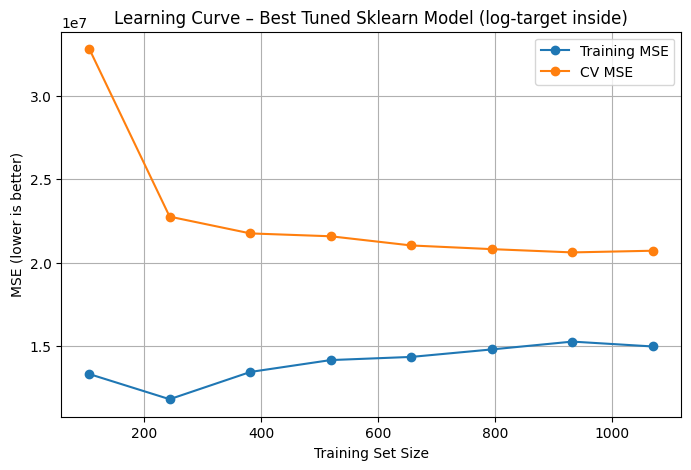

Final gap (CV - Train MSE): 5749695.671991771


In [ ]:
# ============================================================
# 7) Plot Learning Curve (Best sklearn model)
# ============================================================
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_sklearn_model,
    X=X,
    y=y,
    cv=cv,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_STATE,
)

train_mse = -train_scores.mean(axis=1)
val_mse   = -val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mse, marker="o", label="Training MSE")
plt.plot(train_sizes, val_mse, marker="o", label="CV MSE")
plt.xlabel("Training Set Size")
plt.ylabel("MSE (lower is better)")
plt.title("Learning Curve – Best Tuned Sklearn Model (log-target inside)")
plt.legend()
plt.grid(True)
plt.show()

gap = float(val_mse[-1] - train_mse[-1])
print("Final gap (CV - Train MSE):", gap)


Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 51.0939 - mae: 6.6070 - val_loss: 2.1545 - val_mae: 1.1959
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.1774 - mae: 1.4518 - val_loss: 1.3309 - val_mae: 0.9457
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.8220 - mae: 1.0831 - val_loss: 0.7110 - val_mae: 0.6643
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.4336 - mae: 0.9361 - val_loss: 0.4971 - val_mae: 0.5530
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.3057 - mae: 0.8956 - val_loss: 0.3830 - val_mae: 0.4691
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.1406 - mae: 0.8628 - val_loss: 0.3755 - val_mae: 0.4589
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.9882 - mae: 0.7738 - val_loss: 0.2466 - val_mae: 0.3454
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.8875 - mae: 0.7371 - val_loss: 0.2349 - val_mae: 0.3390
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - 

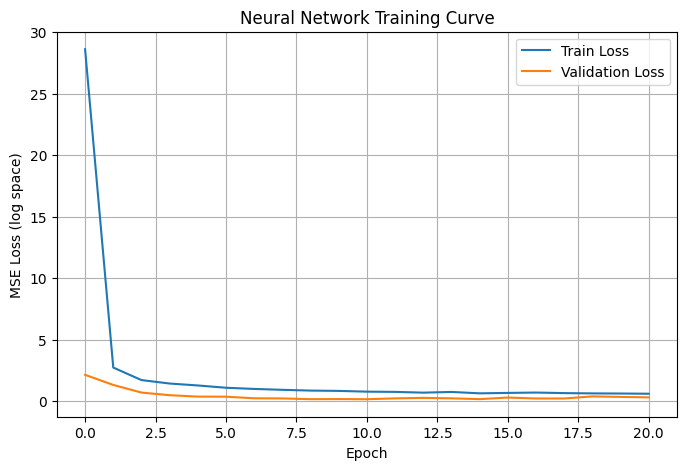

=== Updated Model Ranking (incl. NN) ===


,Model,MSE,RMSE,MAE,R2
0,"XGB (log-target, tuned-ensemble)",1.836712e+07,4285.687266,1925.472572,0.881692
1,"XGB (log-target, tuned)",1.840021e+07,4289.546139,1926.928295,0.881479
2,"XGB (log-target, base)",2.187855e+07,4677.450907,2336.162900,0.859074
3,Neural Network (log-target),3.432187e+07,5858.486874,2715.365967,0.778923
4,Neural Network (log-target),5.312315e+07,7288.563027,3653.340713,0.657819


In [ ]:
# ============================================================
# 8) Neural Network (Keras) + Training Curve
# ============================================================
# Notes:
# - We fit the SAME preprocessor on TRAIN split only, then transform train/valid.
# - For target, we also log1p to stabilize heavy-tail.
# - We'll compare metrics on ORIGINAL scale (expm1 back).

# Install tensorflow if needed
try:
    import tensorflow as tf
except Exception:
    !pip -q install tensorflow
    import tensorflow as tf

# IMPORTANT: copy must be imported regardless
import copy

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Fit preprocessor on training split only (avoid leakage)
preprocessor_nn = copy.deepcopy(preprocessor)
preprocessor_nn.fit(X_tr)

X_tr_nn = preprocessor_nn.transform(X_tr)
X_va_nn = preprocessor_nn.transform(X_va)

y_tr_log = np.log1p(y_tr.values)
y_va_log = np.log1p(y_va.values)

nn_model = Sequential([
    Dense(256, activation="relu", input_shape=(X_tr_nn.shape[1],)),
    Dropout(0.25),
    Dense(128, activation="relu"),
    Dropout(0.20),
    Dense(64, activation="relu"),
    Dense(1)
])

nn_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = nn_model.fit(
    X_tr_nn, y_tr_log,
    validation_data=(X_va_nn, y_va_log),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predict (log space) -> back to original
va_pred_log_nn = nn_model.predict(X_va_nn).reshape(-1)
va_pred_nn = np.expm1(va_pred_log_nn)

# Clip negatives
va_pred_nn = np.maximum(va_pred_nn, 0)

nn_metrics = {
    "Model": "Neural Network (log-target)",
    "MSE": mean_squared_error(y_va, va_pred_nn),
    "RMSE": mean_squared_error(y_va, va_pred_nn) ** 0.5,
    "MAE": mean_absolute_error(y_va, va_pred_nn),
    "R2": r2_score(y_va, va_pred_nn),
}

print("NN validation metrics:")
print(nn_metrics)

# Plot NN training curve (MSE in log space)
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log space)")
plt.title("Neural Network Training Curve")
plt.legend()
plt.grid(True)
plt.show()

# Append to results_df
results_df = pd.concat([results_df, pd.DataFrame([nn_metrics])], ignore_index=True).sort_values("RMSE").reset_index(drop=True)
print("=== Updated Model Ranking (incl. NN) ===")
display(results_df)


In [ ]:
# ============================================================
# 9) H2O AutoML (Stacked Ensemble often strong) + Leaderboard
# ============================================================
# IMPORTANT:
# - H2O needs categorical columns as factors.
# - We'll train on ORIGINAL target scale (charges), but you can try log later.
# - We'll also evaluate on the SAME X_va/y_va split for fair comparison.

# Install h2o if needed
try:
    import h2o
    from h2o.automl import H2OAutoML
except Exception:
    !pip -q install h2o
    import h2o
    from h2o.automl import H2OAutoML

# avoid re-init in same runtime
if not h2o.connection():
    h2o.init()
else:
    print("H2O already initialized:", h2o.connection().base_url)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.0/266.0 MB 5.1 MB/s eta 0:00:00
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.17" 2025-10-21; OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04); OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpx_kf0dll
  JVM stdout: /tmp/tmpx_kf0dll/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpx_kf0dll/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 16 days
H2O_cluster_name:,H2O_from_python_unknownUser_apzmh4
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:
# B) Build H2OFrames
train_df_h2o = pd.concat([X_tr, y_tr], axis=1)
valid_df_h2o = pd.concat([X_va, y_va], axis=1)

h2o_train = h2o.H2OFrame(train_df_h2o)
h2o_valid = h2o.H2OFrame(valid_df_h2o)
h2o_test  = h2o.H2OFrame(df_test_fe.drop(columns=[y_col], errors="ignore"))

target = y_col
features = [c for c in h2o_train.columns if c != target]

print("H2OFrames ready.")
print("train rows:", h2o_train.nrows, "valid rows:", h2o_valid.nrows, "test rows:", h2o_test.nrows)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrames ready.
train rows: 1070 valid rows: 268 test rows: 267


In [ ]:
# C) Ensure categorical columns are factors
for c in cat_cols:
    if c in h2o_train.columns:
        h2o_train[c] = h2o_train[c].asfactor()
        h2o_valid[c] = h2o_valid[c].asfactor()
    if c in h2o_test.columns:
        h2o_test[c] = h2o_test[c].asfactor()

print("Categorical columns set to factor (if present).")

Categorical columns set to factor (if present).


In [ ]:
# D) Run AutoML (slow cell)
aml = H2OAutoML(
    max_models=20,
    seed=42,
    sort_metric="RMSE",
    max_runtime_secs=180
)

aml.train(x=features, y=target, training_frame=h2o_train, validation_frame=h2o_valid)

lb = aml.leaderboard.as_data_frame()
display(lb.head(10))

leader = aml.leader
print("Leader:", leader.model_id)

AutoML progress: |
05:16:33.489: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.

███████████████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,GBM_grid_1_AutoML_1_20260210_51633_model_2,4759.949368,2.265712e+07,2735.815244,0.473741,2.265712e+07
1,GBM_2_AutoML_1_20260210_51633,4764.728165,2.270263e+07,2754.477041,0.467669,2.270263e+07
2,GBM_3_AutoML_1_20260210_51633,4773.897387,2.279010e+07,2750.240027,0.466653,2.279010e+07
3,GBM_4_AutoML_1_20260210_51633,4791.776780,2.296112e+07,2737.895334,0.471531,2.296112e+07
4,GBM_grid_1_AutoML_1_20260210_51633_model_1,4850.782426,2.353009e+07,2784.293436,0.469957,2.353009e+07
5,DRF_1_AutoML_1_20260210_51633,4851.488393,2.353694e+07,2727.874753,0.464369,2.353694e+07
6,GBM_1_AutoML_1_20260210_51633,4858.540519,2.360542e+07,2810.853026,0.433601,2.360542e+07
7,XRT_1_AutoML_1_20260210_51633,4868.230624,2.369967e+07,2768.559081,0.477589,2.369967e+07
8,GBM_5_AutoML_1_20260210_51633,4960.525724,2.460682e+07,2858.382720,0.486423,2.460682e+07
9,DeepLearning_1_AutoML_1_20260210_51633,5105.250706,2.606358e+07,2995.134712,NaN,2.606358e+07


Leader: GBM_grid_1_AutoML_1_20260210_51633_model_2


In [ ]:
# E) Predict with leader
va_pred = leader.predict(h2o_valid).as_data_frame().values.reshape(-1)
test_pred = leader.predict(h2o_test).as_data_frame().values.reshape(-1)

h2o_rmse = float(mean_squared_error(y_va, va_pred) ** 0.5)
print("H2O Leader RMSE on validation:", h2o_rmse)

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
H2O Leader RMSE on validation: 4473.421770690007


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [ ]:
import os
import numpy as np
import pandas as pd

# detect if in Colab
try:
    from google.colab import files
    IN_COLAB = True
except:
    IN_COLAB = False

print("IN_COLAB =", IN_COLAB)

IN_COLAB = True


## 10) Model Comparison → Choose Best (Kaggle metric: RMSE/MSE)

We compare models on the **same validation split** and select the best by **lowest RMSE** (equivalently lowest MSE).  
Then we fit the chosen model on full training data and generate `submit.csv` for Kaggle.

In [ ]:
# 10. Model Comparison + Best model
# ---- H2O AutoML prediction only ----
# assumes leader + h2o_test_full already exist

h2o_preds = leader.predict(h2o_test)
h2o_preds_df = h2o_preds.as_data_frame()

# prediction usually in first column
test_pred = h2o_preds_df.iloc[:, 0].values

print("Pred shape:", test_pred.shape)
print("Pred preview:", test_pred[:5])

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Pred shape: (267,)
Pred preview: [12918.38901582 15084.13662567  6058.21666374 38028.42375793
  3198.41741409]


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [ ]:
# Build IDs
if "ID" in df_test.columns:
    IDs = df_test["ID"].values
elif "id" in df_test.columns:
    IDs = df_test["id"].values
else:
    IDs = np.arange(1, len(df_test) + 1)

submission = pd.DataFrame({
    "ID": IDs,
    "Target": test_pred
})

# Safety checks
assert len(submission) == len(df_test), "Row mismatch between submission and test!"
assert submission["Target"].notna().all(), "NaNs found in Target!"
assert np.isfinite(submission["Target"]).all(), "Inf found in Target!"

file_name = "submit.csv"
submission.to_csv(file_name, index=False)

print("✅ submit.csv created.")
print("Saved at:", os.path.abspath(file_name))
submission.head()

✅ submit.csv created.
Saved at: /content/submit.csv


,ID,Target
0,1,12918.389016
1,2,15084.136626
2,3,6058.216664
3,4,38028.423758
4,5,3198.417414


In [ ]:
if IN_COLAB:
    print("⬇️ Triggering download.")
    files.download(file_name)
else:
    print("Not running in Colab, skip auto-download.")

⬇️ Triggering download.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>